## Grouped CANS Cox Model

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../..').resolve()))

from cox_utils import (
    load_data, cox_incident_table, build_cox_df, fit_cox_model,
    plot_cox_coefs, plot_prior_incident_risk_curve, drill_down,
    plot_partial_effects, plot_90day_probability,
    check_cox_assumptions, plot_profile_risk,
    DEMO_COLS
)

INCIDENT_CAT = 'Abuse_CPS_Report'
INCIDENT_DISPLAY = 'Abuse_CPS_Report'



## Build Incident-Related Cox Table

In [25]:
dfs, top_n_cols, base_cols, incident_cols_dict, group_cols = load_data()
incident_related_cox_table = cox_incident_table(INCIDENT_CAT, dfs, base_cols, incident_cols_dict)

Found 3 data files. Loading...
Duplicates Removed: 2836
Excluded 591 rows: invalid QuestionKey, missing ChoiceValue, or non-max ChoiceValue within group
1. Initial top_n count: 45
2. Count after removing Index columns: 43
3. Degenerate rows excluded: 48
5. All features have variance.


## Fit Grouped Cox Model

In [16]:
cox_df = build_cox_df(incident_related_cox_table, INCIDENT_CAT, group_cols)
cph = fit_cox_model(cox_df, INCIDENT_CAT)
cph.summary

Shape: (3231, 20)
Events: 219


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
Caregiver_Support_Needs,0.030017,1.030472,0.019304,-0.007819,0.067853,0.992212,1.070208,0.0,1.554938,0.119961,3.059364
Internalizing_/_Self-Harm,0.044832,1.045852,0.022496,0.000742,0.088923,1.000742,1.092996,0.0,1.992932,0.046269,4.433815
Developmental_&_Sexual_Concerns,-0.014897,0.985214,0.052442,-0.117682,0.087888,0.888979,1.091866,0.0,-0.284061,0.776364,0.365195
Externalizing_Behavior,0.023905,1.024193,0.024501,-0.024116,0.071925,0.976173,1.074575,0.0,0.975678,0.329224,1.602858
Family_&_Social_Functioning,0.089870,1.094032,0.037012,0.017328,0.162412,1.017479,1.176344,0.0,2.428151,0.015176,6.042062
Community_&_Strengths,-0.012038,0.988034,0.031205,-0.073198,0.049121,0.929417,1.050348,0.0,-0.385786,0.699655,0.515284
Substance_Use_&_Delinquency,-0.069631,0.932738,0.060387,-0.187987,0.048725,0.828626,1.049931,0.0,-1.153085,0.248876,2.006504
School_Functioning,0.009068,1.009109,0.030977,-0.051646,0.069782,0.949665,1.072275,0.0,0.292730,0.769728,0.377579
Black,-1.358839,0.256959,0.355692,-2.055983,-0.661696,0.127967,0.515976,0.0,-3.820269,0.000133,12.872968


## Model Assumption Checks

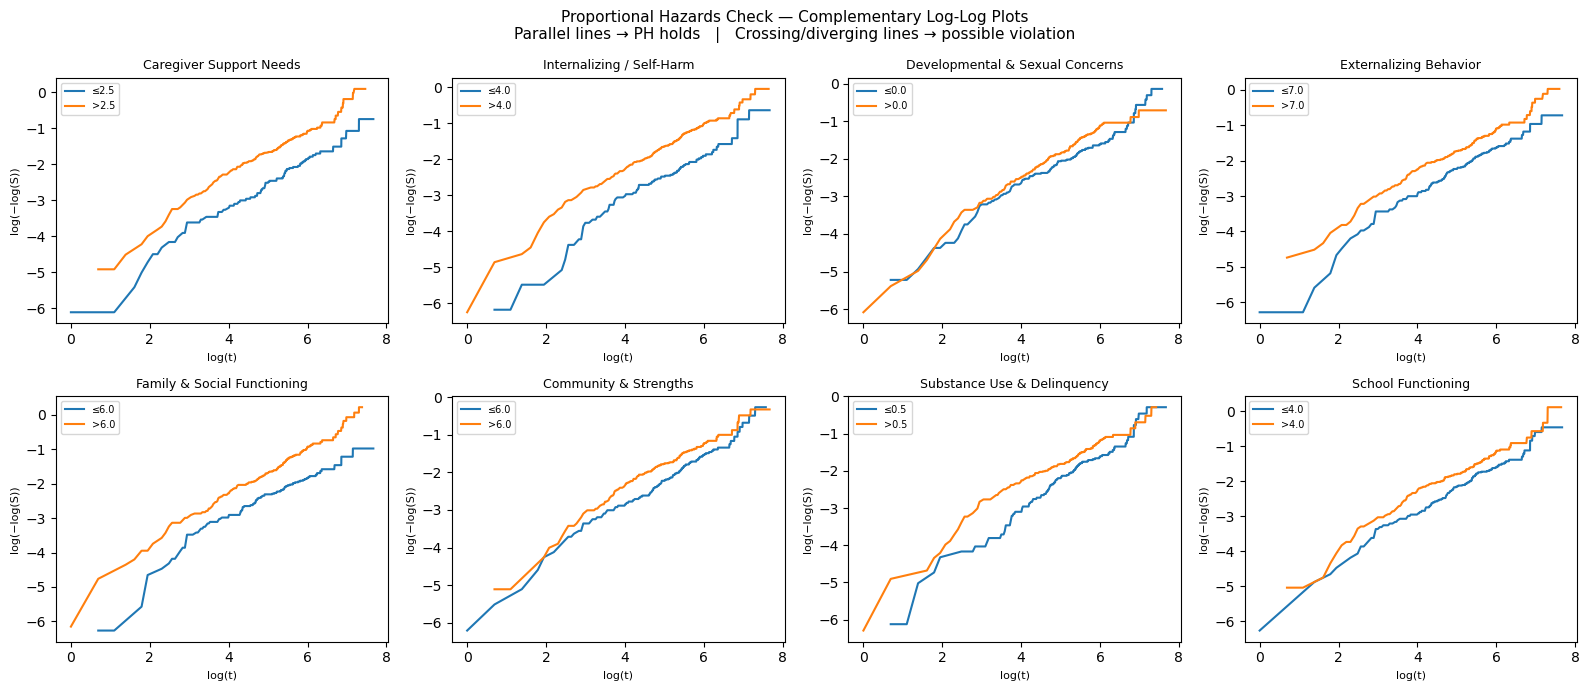

Concordance Index: 0.7114  (0.5 = random, 1.0 = perfect discrimination)


In [17]:
check_cox_assumptions(cph, cox_df, covariates=group_cols)

Each panel shows a **complementary log-log (cll) plot** for one covariate. The y-axis is log(−log(S(t))) and the x-axis is log(t), where S(t) is the Kaplan-Meier survival estimate. Binary covariates are split on their two values; continuous and ordinal covariates are split at the median into a low (≤ median) and high (> median) group. Under the proportional hazards assumption, the two lines for each covariate should run roughly **parallel** across the time axis — a constant vertical offset on the log(−log) scale corresponds to a constant hazard ratio. **Crossing or strongly diverging lines** indicate that the hazard ratio between the two groups changes over time, which is a violation of the PH assumption and suggests that covariate may need to be modeled with a time-varying interaction or stratification. The concordance index printed above the plots summarizes overall model discrimination (0.5 = random, 1.0 = perfect).

## Visualize Group Coefficients

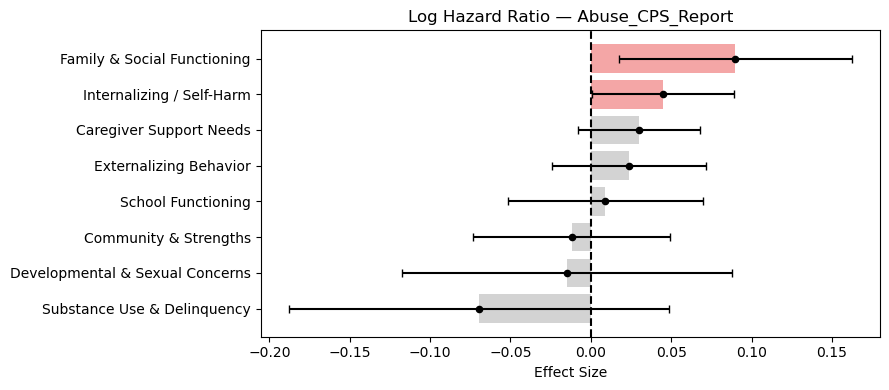

In [18]:
plot_cox_coefs(
    cph,
    exclude_vars=DEMO_COLS + [
        INCIDENT_CAT + '_days_since_last_incident',
        INCIDENT_CAT + '_prior_incident_count'
    ],
    title=f"Log Hazard Ratio — {INCIDENT_DISPLAY}"
)

## Prior Incident Count: Survival Risk Curves

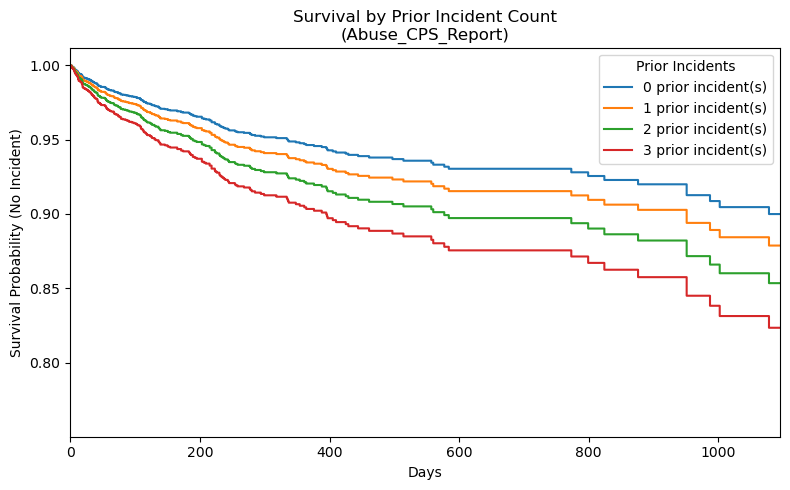

In [19]:
plot_prior_incident_risk_curve(cph, INCIDENT_CAT, INCIDENT_DISPLAY)

## Drill Down: Individual Items in Top Risk Group

Top risk group: Family_&_Social_Functioning
Items in group: ['Family Function', 'Social Functioning', 'Living Situation', 'Family Strengths', 'Interpersonal']


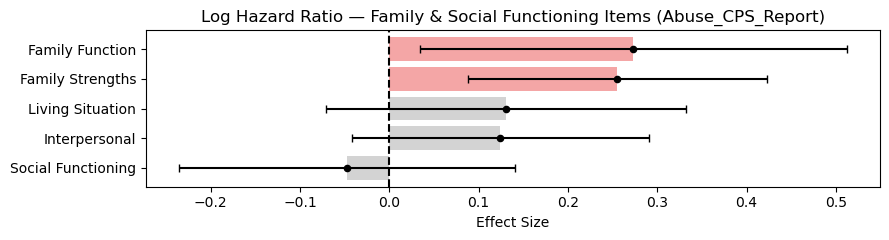


Top 3 most impactful CANS scores:
  Family Function: coef = 0.2733, p = 2.4878e-02
  Family Strengths: coef = 0.2553, p = 2.8440e-03
  Living Situation: coef = 0.1306, p = 2.0465e-01


In [20]:
cph_drill, drill_df, top_items = drill_down(
    cph, group_cols, incident_related_cox_table, INCIDENT_CAT, INCIDENT_DISPLAY
)

## Partial Effects: Survival Curves for Top 3 CANS Scores

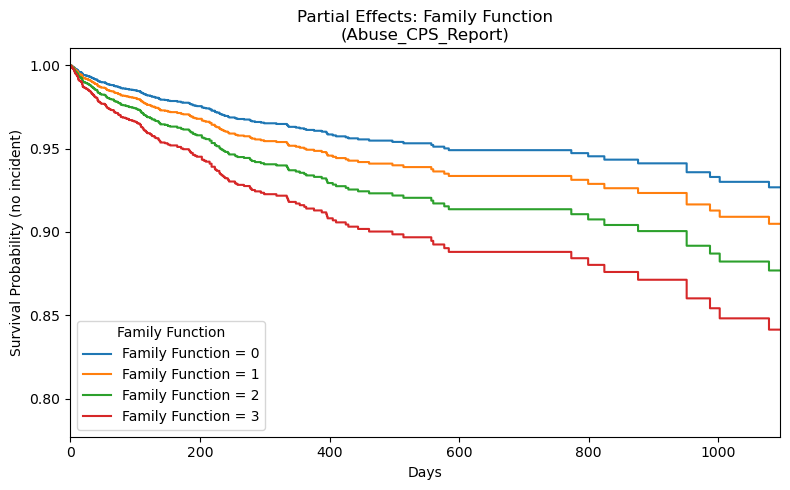

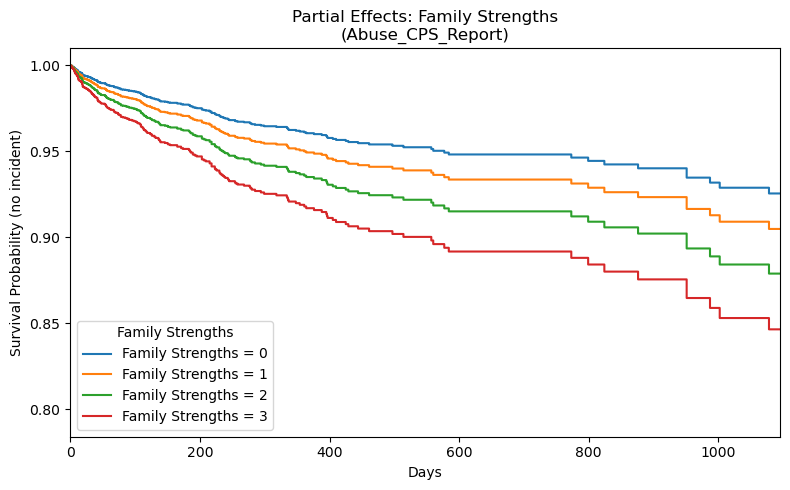

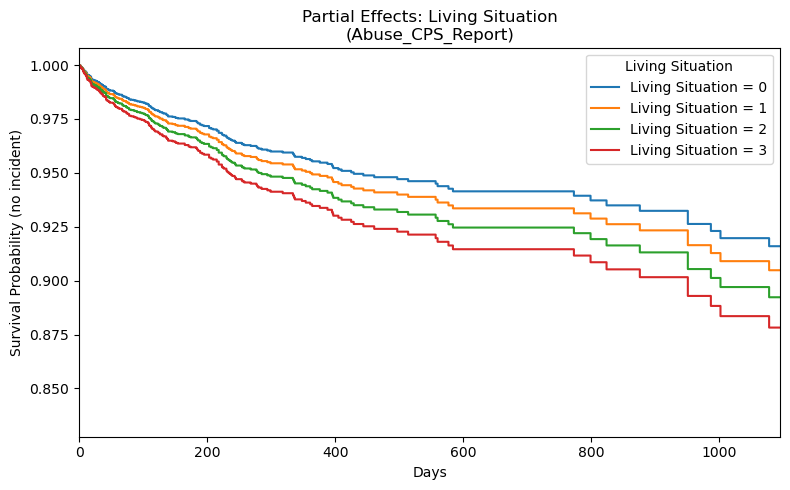

In [21]:
plot_partial_effects(cph_drill, top_items, INCIDENT_DISPLAY)

## 90-Day Incident Probability by Top 3 CANS Score Values

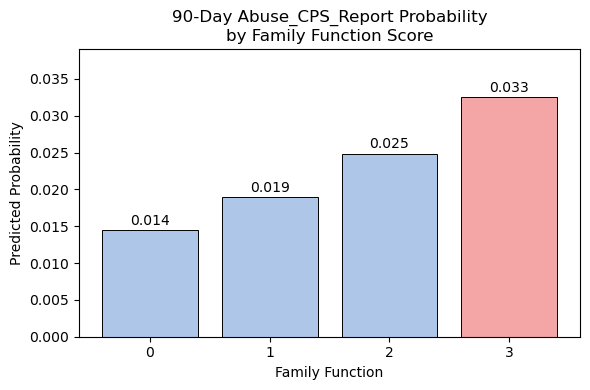

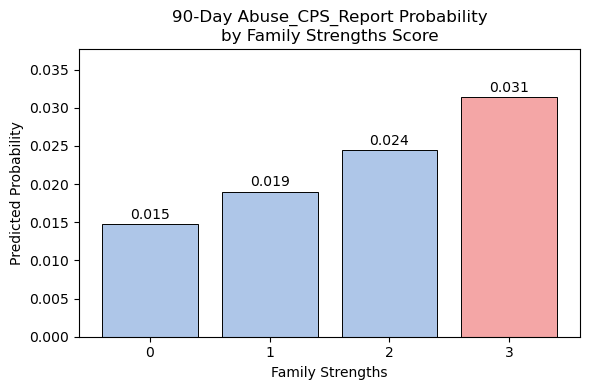

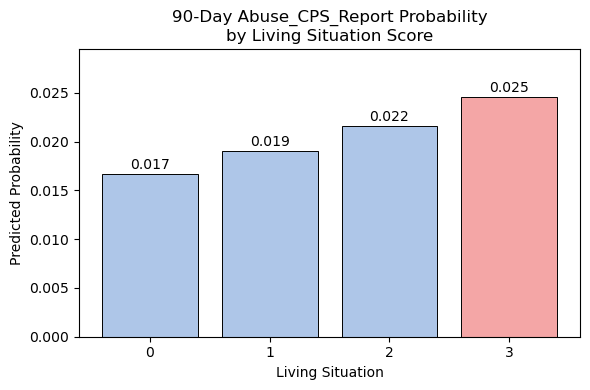

In [22]:
plot_90day_probability(cph_drill, drill_df, INCIDENT_CAT, top_items, INCIDENT_DISPLAY)

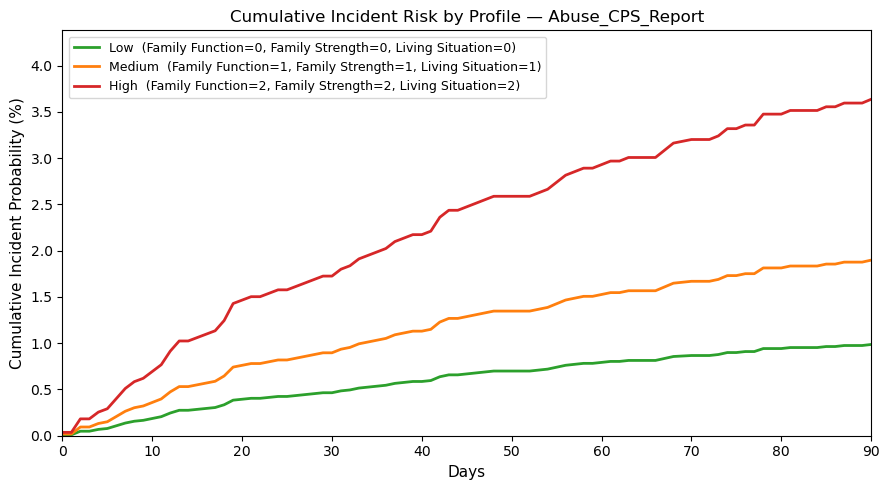

In [24]:
profiles={
        'Low':    {'Family Function': 0, 'Family Strength': 0, 'Living Situation': 0},
        'Medium': {'Family Function': 1, 'Family Strength': 1, 'Living Situation': 1},
        'High':   {'Family Function': 2, 'Family Strength': 2, 'Living Situation': 2},
    }

plot_profile_risk(
    cph_drill, drill_df, INCIDENT_CAT,
   profiles=profiles,
    incident_display=INCIDENT_DISPLAY
);